<a href="https://colab.research.google.com/github/heet25itachi/PROJECT---2026-/blob/main/FITTING_PARADOX%26REGULARIZATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

OVerfitted Model Training MSE: 0.038551 (Near Zero)
Regularized Model Training MSE: 0.066706 (Intentionally Higher)


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.9328e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


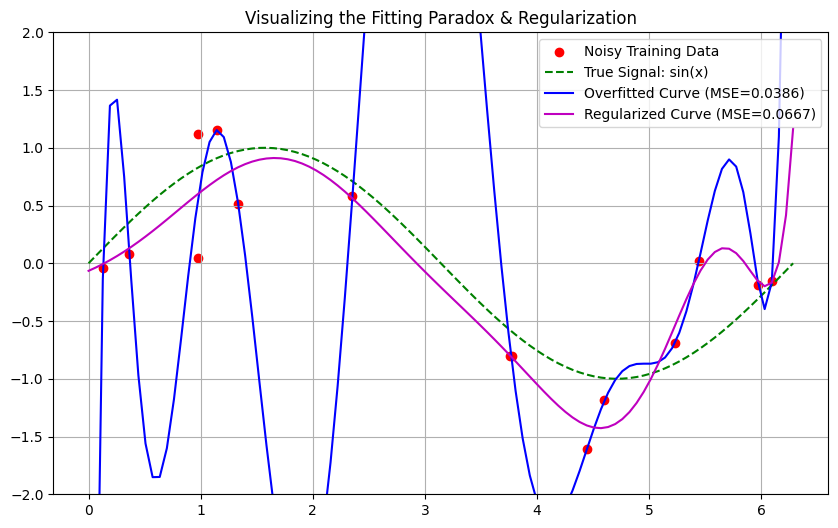

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error

#1. Generate synthetic data with explicit nosie: y = sin(x) + noise
np.random.seed(42)
x = np.sort(np.random.uniform(0, 2 * np.pi, 15))
noise = np.random.normal(0, 0.3, len(x))

# Dense points for evaluting the true vs. predicted curves
x_dense = np.linspace(0, 2 * np.pi, 100)
y_true = np.sin(x_dense)

#2. Overfitted Model: 12th-degree Polynomial + L2 Penalty (Ridge)
regularized_model = make_pipeline(PolynomialFeatures(degree=12), Ridge(alpha=0.1))
regularized_model.fit(x.reshape(-1, 1), y)
y_pred_reg = regularized_model.predict(x_dense.reshape(-1, 1))

# Calculate empirical training errors
err_overfit = mean_squared_error(y, overfit_model.predict(x.reshape(-1, 1)))
err_reg = mean_squared_error(y, regularized_model.predict(x.reshape(-1, 1)))

print(f"OVerfitted Model Training MSE: {err_overfit:.6f} (Near Zero)")
print(f"Regularized Model Training MSE: {err_reg:.6f} (Intentionally Higher)")

# 4. Plot the results to visualize the boundary lines
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='red', label='Noisy Training Data')
plt.plot(x_dense, y_true, 'g--', label='True Signal: sin(x)')
plt.plot(x_dense, y_pred_overfit, 'b-', label=f'Overfitted Curve (MSE={err_overfit:.4f})')
plt.plot(x_dense, y_pred_reg, 'm-', label=f'Regularized Curve (MSE={err_reg:.4f})')
plt.ylim(-2, 2)
plt.legend()
plt.title("Visualizing the Fitting Paradox & Regularization")
plt.grid(True)
plt.show()